In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

import joblib

In [41]:
df=pd.read_csv(
    "../data/processed/zomato_cleaned.csv"
)

In [42]:
df['approx_cost']=df['approx_costfor_two_people']/2
df[['approx_cost',"approx_costfor_two_people"]]

,approx_cost,approx_costfor_two_people
0,400.0,800.0
1,400.0,800.0
2,400.0,800.0
3,150.0,300.0
4,300.0,600.0
...,...,...
12135,200.0,400.0
12136,200.0,400.0
12137,200.0,400.0
12138,200.0,400.0


In [57]:
df.head()

,url,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,...,listed_incity,popularity_score,price_tier,locality_avg_rating,above_locality_avg,rest_type_count,cuisine_count,log_votes,approx_cost,dbscan_cluster
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,1,1,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",...,Banashankari,3177.5,high,3.647350,1,1,3,6.654153,400.0,0
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,1,0,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",...,Banashankari,3226.7,high,3.647350,1,1,3,6.669498,400.0,0
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,1,0,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",...,Banashankari,3488.4,high,3.647350,1,2,3,6.823286,400.0,2
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,0,0,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",...,Banashankari,325.6,low,3.647350,1,1,2,4.488636,150.0,0
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,0,0,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",...,Banashankari,630.8,medium,3.681463,1,1,2,5.117994,300.0,0


In [43]:
features=[
    "rate",
    "votes",
    "approx_cost",
    'popularity_score',
    "locality_avg_rating",
    "above_locality_avg",
    "rest_type_count",
    "cuisine_count",
    "log_votes"
]

In [44]:
X=df[features]

In [45]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [46]:
neghbors=NearestNeighbors(
    n_neighbors=5
)

In [47]:
neghbors_fit=neghbors.fit(X_scaled)

In [48]:
distance,indices=neghbors_fit.kneighbors(X_scaled)

In [49]:
distance=np.sort(
    distance[:,4]
)


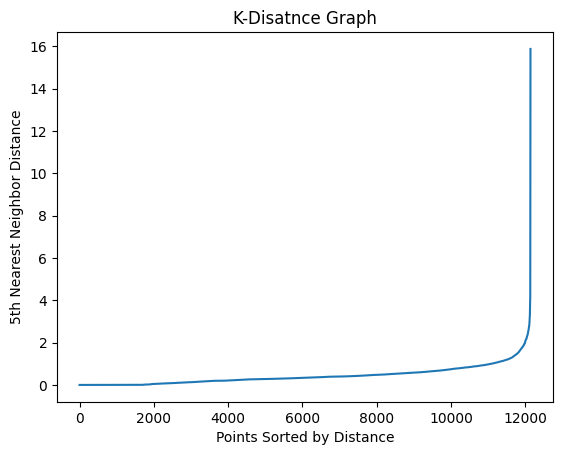

In [50]:
plt.Figure(figsize=(8,5))
plt.plot(distance)
plt.xlabel("Points Sorted by Distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-Disatnce Graph")
plt.savefig(
    "../images/k_distance_graph.png"
)
plt.show()

In [51]:
dbscan=DBSCAN(
    eps=1.5,
    min_samples=5
)

In [52]:
df['dbscan_cluster']=dbscan.fit_predict(
    X_scaled
)

In [53]:
df['dbscan_cluster'].value_counts()

dbscan_cluster
 0    6081
 1    4238
 2    1017
 3     571
-1     224
 5       5
 4       4
Name: count, dtype: int64

In [54]:
noise_points=(df['dbscan_cluster']==-1).sum()
noise_points

np.int64(224)

In [55]:
noise_restaurants=df[df['dbscan_cluster']==-1]

In [58]:
noise_restaurants[
    [
        "name",
        "rate",
        "votes",
        "approx_cost",
        "popularity_score"
    ]
].head(20)

,name,rate,votes,approx_cost,popularity_score
37,Empire Restaurant,4.4,4884,75.0,21489.6
53,FreshMenu,3.9,627,400.0,2445.3
63,Kabab Magic,4.1,1720,600.0,7052.0
84,Meghana Foods,4.4,4401,250.0,19364.4
426,Starlite Bakery & Fastfood,3.7,0,400.0,0.0
553,Vidyarthi Bhavan,4.4,4460,450.0,19624.0
590,Fattoush,4.2,1964,100.0,8248.8
591,Empire Restaurant,4.3,3178,400.0,13665.4
594,Barbeque Nation,4.7,3845,300.0,18071.5
647,eat.fit,4.5,1178,550.0,5301.0


In [59]:
noise_restaurants.to_csv(
    "../reports/dbscan_noise_points.csv",
    index=False
)

In [60]:
comparison_df = pd.DataFrame({

    "Method": [
        "KMeans",
        "DBSCAN"
    ],

    "Cluster_Style": [
        "Centroid-Based",
        "Density-Based"
    ],

    "Handles_Outliers": [
        "No",
        "Yes"
    ],

    "Requires_K": [
        "Yes",
        "No"
    ]
})

comparison_df

,Method,Cluster_Style,Handles_Outliers,Requires_K
0,KMeans,Centroid-Based,No,Yes
1,DBSCAN,Density-Based,Yes,No


In [61]:
comparison_df.to_csv(
    "../reports/clustering_comparison.csv",
    index=False
)

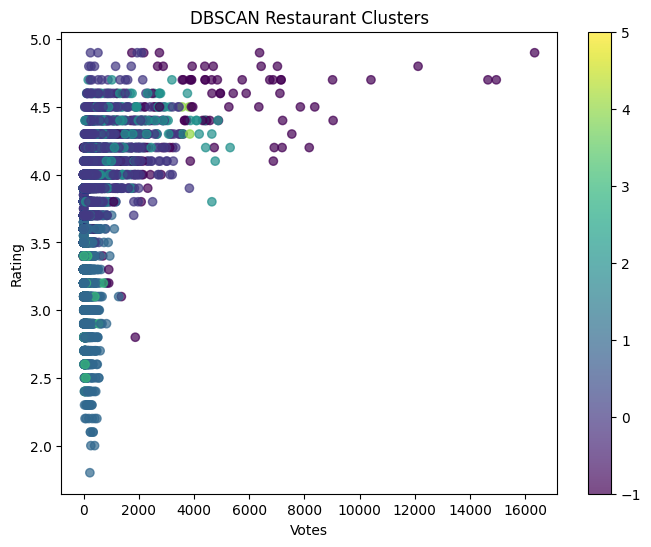

In [63]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(

    df["votes"],

    df["rate"],

    c=df["dbscan_cluster"],

    cmap="viridis",

    alpha=0.7
)

plt.xlabel("Votes")

plt.ylabel("Rating")

plt.title("DBSCAN Restaurant Clusters")

plt.colorbar(scatter)
plt.savefig(
    "../images/dbscan_clusters.png",
    bbox_inches="tight"
)

plt.show()

In [64]:
joblib.dump(
    dbscan,
    "../models/dbscan_model.pkl"
)

['../models/dbscan_model.pkl']

In [65]:
df.to_csv(
    "../data/processed/zomato_dbscan.csv",
    index=False
)

# Hour 2 Conclusions

1. DBSCAN clustering was applied for density-based restaurant segmentation.
2. k-distance analysis was used to determine the eps parameter.
3. DBSCAN successfully identified noise/anomalous restaurants.
4. Density-based clustering captured irregular restaurant group structures better than KMeans.
5. Noise points represented potentially viral, niche, or underperforming restaurants.
6. DBSCAN demonstrated advantages in handling outliers and arbitrary cluster shapes.